# Analysis of variance (ANOVA)

## Libraries and settings

In [25]:
# Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Settings for seaborn
sns.set_theme(style="ticks", palette="pastel")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Get current working directory
print('Current working directory:', os.getcwd())

Current working directory: /workspaces/data_analytics/Week_06


## Read example data (used car data)

In [26]:
# Read data
df = pd.read_excel('t-tests_and_ANOVA.xlsx', sheet_name='anova_data')

# Show categories of 'Make'
print(df['Make'].value_counts())

# Show header
df.head()

Make
VW      20
BMW     20
Fiat    20
Name: count, dtype: int64


,Make,Price
0,VW,29000
1,VW,38000
2,VW,33000
3,VW,64000
4,VW,52000


## Create pivot table of mean price per make

In [27]:
# Create pivot table
table = pd.pivot_table(df, 
                       values='Price',
                       columns=['Make'], 
                       aggfunc=np.mean)
print(table)

Make       BMW     Fiat       VW
Price  54000.0  34000.0  41950.0


## Create grouped boxplot (groups = make, values = prices)

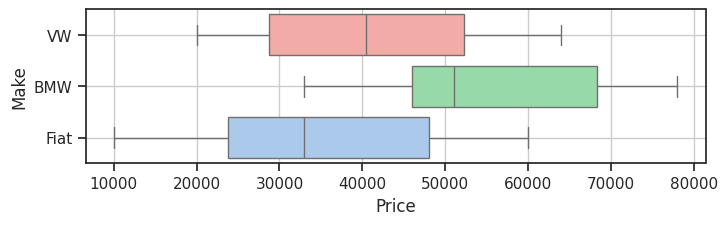

In [28]:
# Plot boxplot with groups
plt.figure(figsize=(8,2))
ax = sns.boxplot(x="Price",
                 y="Make",
                 palette=['r', 'g', 'b'],
                 data=df,
                 orient='h')
plt.grid()
plt.show()

## Analysis of variance (ANOVA)

In [29]:
# Create subsets (groups)
vw = df.loc[df['Make'] == 'VW']
bmw = df.loc[df['Make'] == 'BMW']
fiat = df.loc[df['Make'] == 'Fiat']

# Create ANOVA
fvalue, pvalue = stats.f_oneway(vw['Price'],
                                fiat['Price'], 
                                bmw['Price'])

# Print results
print('F-value:', fvalue.round(3), 'p-value', pvalue.round(4))

F-value: 9.791 p-value 0.0002


## Interpretation of result

<p> Because the p-value is lower than 0.05, the null hypothesis can be rejected, i.e. there is evidence that the used car prices of VW, BMW and Fiat differ. Note that, from the ANOVA, it is not clear which groups show differences of prices. For this a post-hoc test could be used (not part of the exercises).</p>

## Importing apartment data

In [30]:
# Read the data to a pandas data frame
df = pd.read_csv('apartments_data_enriched_cleaned.csv', 
                 sep=';', 
                 encoding='utf-8')[['web-scraper-order',
                                    'address_raw',
                                    'lat',
                                    'lon',
                                    'bfs_number',
                                    'bfs_name',
                                    'rooms', 
                                    'area', 
                                    'luxurious', 
                                    'price', 
                                    'price_per_m2',
                                    'pop_dens',
                                    'frg_pct',
                                    'mean_taxable_income',
                                    'dist_supermarket']]

# Get number of rows and columns
print(df.shape)

# Show first records
df.head(5)

(774, 15)


,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop_dens,frg_pct,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH),3.0,49,0,1441,29.41,1221.272366,24.841283,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",47.252087,8.854919,118,Rüti (ZH),3.0,111,0,2600,23.42,1221.272366,24.841283,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",47.253670,8.853993,118,Rüti (ZH),3.0,58,0,1490,25.69,1221.272366,24.841283,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",47.259834,8.851705,118,Rüti (ZH),4.0,118,0,3240,27.46,1221.272366,24.841283,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",47.266113,8.866872,118,Rüti (ZH),3.0,66,0,1450,21.97,1221.272366,24.841283,65362.04268,974.844209


## Create pivot table with mean price_per_m2 per room size

In [31]:
# Using pivot_table to reshape the data and calculate means 
pd.pivot_table(df[['rooms', 'price_per_m2']],
               index=['rooms'],
               values=['price_per_m2'],
               aggfunc=[np.mean, 'count'])

,mean,count
,price_per_m2,price_per_m2
rooms,,
1.0,47.140400,50
1.5,59.417576,33
2.0,40.757105,38
2.5,37.391631,141
3.0,28.677955,44
3.5,29.942956,203
4.0,29.646429,28
4.5,26.493436,163


## Create grouped boxplot (groups = rooms, values = prices_per_m2)

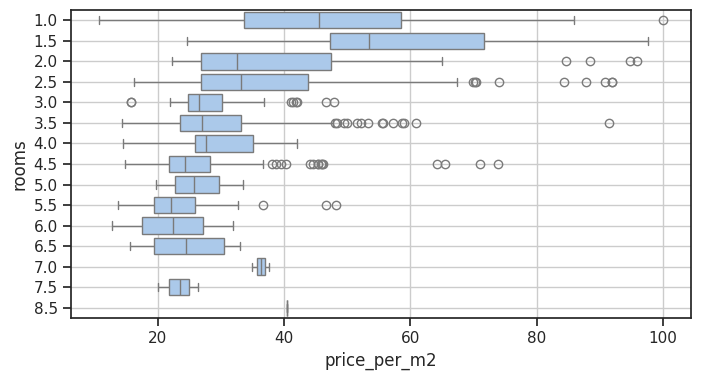

In [32]:
# Plot boxplot with groups
plt.figure(figsize=(8,4))
ax = sns.boxplot(x="price_per_m2",
                 y="rooms",
                 data=df,
                 orient='h')
plt.grid()
plt.show()

## ANOVA to compare the price_per_m2 per number of rooms (= groups)

In [33]:
# Create subsets (groups)
r2_5 = df.loc[df['rooms'] == 2.5]['price_per_m2']
r3_5 = df.loc[df['rooms'] == 3.5]['price_per_m2']
r4_5 = df.loc[df['rooms'] == 4.5]['price_per_m2']

# Create ANOVA
fvalue, pvalue = stats.f_oneway(r2_5, r3_5, r4_5)

# Print results
print('F-value:', fvalue.round(3), 'p-value', pvalue.round(4))

F-value: 34.26 p-value 0.0


## Interpretation of result

<p> Because the p-value is lower than 0.05, the null hypothesis can be rejected, i.e. there is evidence that the price per m2 differ between apartments with 2.5, 3.5 and 4.5 rooms. Note that, from the ANOVA, it is not clear which groups show price differences. For this a post-hoc test could be used (not part of the exercises).</p>

# ANOVA: Vergleich von Gemeinden nach Bevölkerungsdichte

In [34]:
# b) Erstelle drei Subsets nach Bevölkerungsdichte
df_low_dens = df.loc[df['pop_dens'] <= 600]
df_moderate_dens = df.loc[(df['pop_dens'] > 600) & (df['pop_dens'] <= 1500)]
df_high_dens = df.loc[df['pop_dens'] > 1500]

print("Anzahl Wohnungen pro Gruppe:")
print(f"  Niedrige Dichte (≤600):        {len(df_low_dens)}")
print(f"  Mittlere Dichte (600-1500):    {len(df_moderate_dens)}")
print(f"  Hohe Dichte (>1500):           {len(df_high_dens)}")

Anzahl Wohnungen pro Gruppe:
  Niedrige Dichte (≤600):        105
  Mittlere Dichte (600-1500):    217
  Hohe Dichte (>1500):           452


# c ANOVA: Preise pro m²

In [35]:
print("=" * 80)
print("ANOVA 1: MIETPREISE PRO M²")
print("=" * 80)

# Hypothesen
print("\nNull-Hypothese (H0): Die mittleren Mietpreise pro m² sind in allen drei")
print("                     Bevölkerungsdichte-Gruppen gleich.")
print("Alternativ-Hypothese (H1): Mindestens eine Gruppe hat einen unterschiedlichen")
print("                           mittleren Mietpreis pro m².")
print("\nSignifikanz-Level: α = 0.05")
print("-" * 80)

# Deskriptive Statistik
print("\nDeskriptive Statistik - Preise pro m²:")
print(f"  Niedrige Dichte:  Mean = {df_low_dens['price_per_m2'].mean():.2f} CHF/m², Std = {df_low_dens['price_per_m2'].std():.2f}")
print(f"  Mittlere Dichte:  Mean = {df_moderate_dens['price_per_m2'].mean():.2f} CHF/m², Std = {df_moderate_dens['price_per_m2'].std():.2f}")
print(f"  Hohe Dichte:      Mean = {df_high_dens['price_per_m2'].mean():.2f} CHF/m², Std = {df_high_dens['price_per_m2'].std():.2f}")

ANOVA 1: MIETPREISE PRO M²

Null-Hypothese (H0): Die mittleren Mietpreise pro m² sind in allen drei
                     Bevölkerungsdichte-Gruppen gleich.
Alternativ-Hypothese (H1): Mindestens eine Gruppe hat einen unterschiedlichen
                           mittleren Mietpreis pro m².

Signifikanz-Level: α = 0.05
--------------------------------------------------------------------------------

Deskriptive Statistik - Preise pro m²:
  Niedrige Dichte:  Mean = 23.57 CHF/m², Std = 5.45
  Mittlere Dichte:  Mean = 25.98 CHF/m², Std = 6.94
  Hohe Dichte:      Mean = 38.32 CHF/m², Std = 16.65


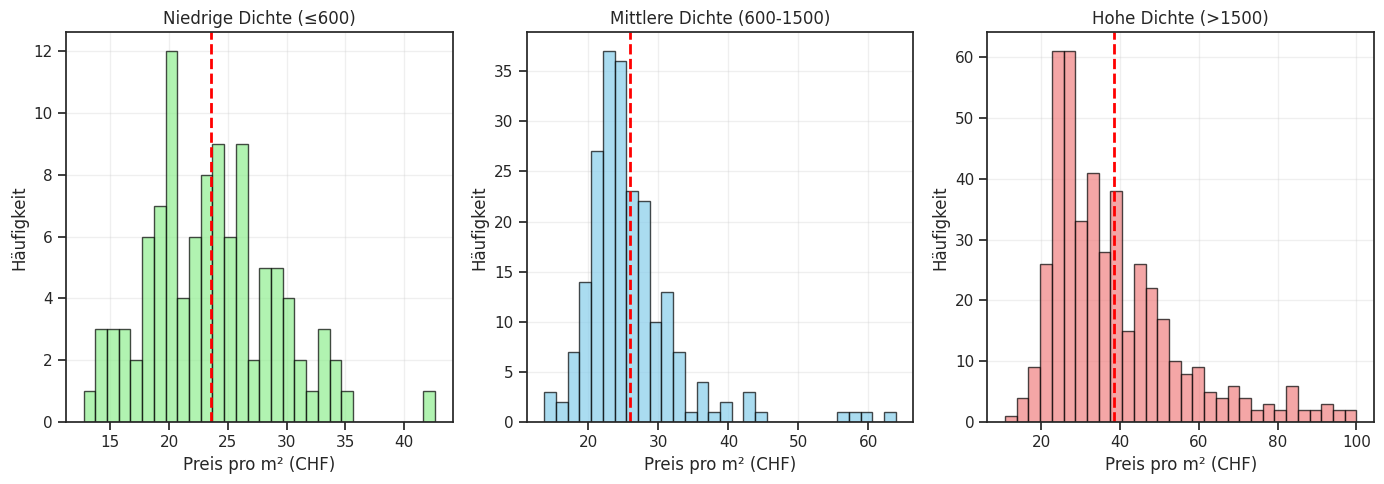

In [36]:
# Visualisierung der Preisverteilungen
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(df_low_dens['price_per_m2'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
plt.axvline(df_low_dens['price_per_m2'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Niedrige Dichte (≤600)')
plt.xlabel('Preis pro m² (CHF)')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(df_moderate_dens['price_per_m2'], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
plt.axvline(df_moderate_dens['price_per_m2'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Mittlere Dichte (600-1500)')
plt.xlabel('Preis pro m² (CHF)')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(df_high_dens['price_per_m2'], bins=30, color='lightcoral', alpha=0.7, edgecolor='black')
plt.axvline(df_high_dens['price_per_m2'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Hohe Dichte (>1500)')
plt.xlabel('Preis pro m² (CHF)')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# ANOVA durchführen
from scipy import stats

f_statistic_price, p_value_price = stats.f_oneway(
    df_low_dens['price_per_m2'],
    df_moderate_dens['price_per_m2'],
    df_high_dens['price_per_m2']
)

print(f"\nF-Statistik: {f_statistic_price:.4f}")
print(f"p-Wert: {p_value_price:.6f}")

# Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION - PREISE PRO M²")
print("=" * 80)

if p_value_price < 0.05:
    print(f"\n✓ Der p-Wert ({p_value_price:.6f}) ist kleiner als α = 0.05.")
    print("→ Wir VERWERFEN die Null-Hypothese.")
    print("\nKONKLUSION:")
    print("Es gibt einen statistisch signifikanten Unterschied bei den Mietpreisen pro m²")
    print("zwischen den drei Bevölkerungsdichte-Gruppen.")
    print("\nJe höher die Bevölkerungsdichte, desto höher tendenziell die Mietpreise.")
else:
    print(f"\n✗ Der p-Wert ({p_value_price:.6f}) ist größer als α = 0.05.")
    print("→ Wir können die Null-Hypothese NICHT verwerfen.")
    print("\nKONKLUSION:")
    print("Es gibt KEINEN statistisch signifikanten Unterschied bei den Mietpreisen pro m²")
    print("zwischen den drei Bevölkerungsdichte-Gruppen.")

print("=" * 80)


F-Statistik: 91.2723
p-Wert: 0.000000

INTERPRETATION - PREISE PRO M²

✓ Der p-Wert (0.000000) ist kleiner als α = 0.05.
→ Wir VERWERFEN die Null-Hypothese.

KONKLUSION:
Es gibt einen statistisch signifikanten Unterschied bei den Mietpreisen pro m²
zwischen den drei Bevölkerungsdichte-Gruppen.

Je höher die Bevölkerungsdichte, desto höher tendenziell die Mietpreise.


# d ANOVA: Flächen der Wohnungen

In [38]:
print("\n" + "=" * 80)
print("ANOVA 2: WOHNUNGSFLÄCHEN")
print("=" * 80)

# Hypothesen
print("\nNull-Hypothese (H0): Die mittleren Wohnungsflächen sind in allen drei")
print("                     Bevölkerungsdichte-Gruppen gleich.")
print("Alternativ-Hypothese (H1): Mindestens eine Gruppe hat eine unterschiedliche")
print("                           mittlere Wohnungsfläche.")
print("\nSignifikanz-Level: α = 0.05")
print("-" * 80)

# Deskriptive Statistik
print("\nDeskriptive Statistik - Flächen:")
print(f"  Niedrige Dichte:  Mean = {df_low_dens['area'].mean():.2f} m², Std = {df_low_dens['area'].std():.2f}")
print(f"  Mittlere Dichte:  Mean = {df_moderate_dens['area'].mean():.2f} m², Std = {df_moderate_dens['area'].std():.2f}")
print(f"  Hohe Dichte:      Mean = {df_high_dens['area'].mean():.2f} m², Std = {df_high_dens['area'].std():.2f}")1

SyntaxError: invalid syntax (2305743518.py, line 17)

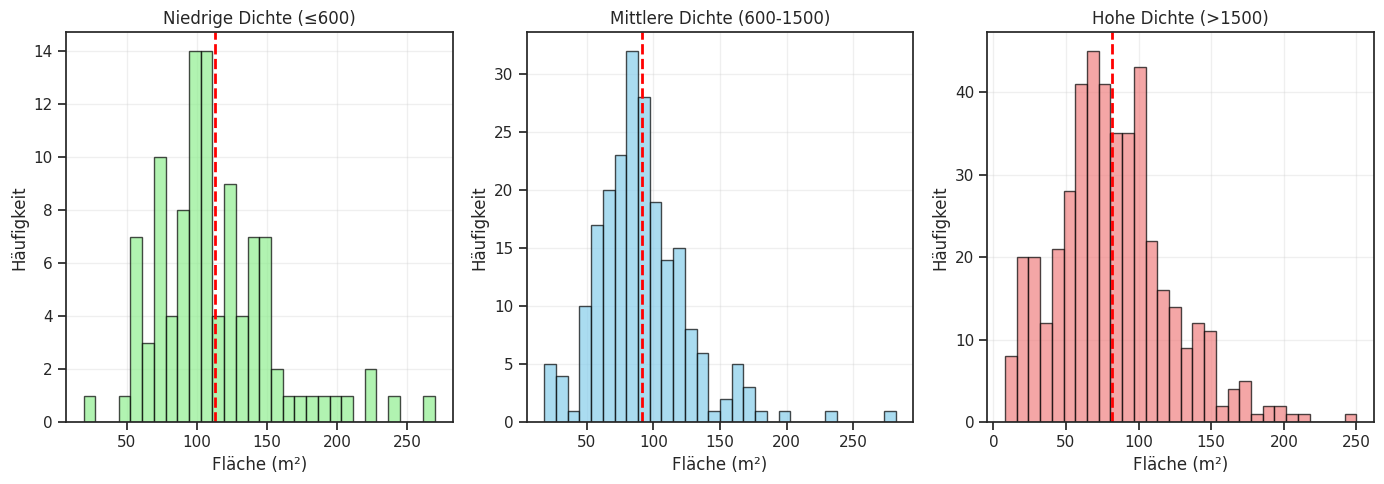

In [39]:
# Visualisierung der Flächenverteilungen
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(df_low_dens['area'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
plt.axvline(df_low_dens['area'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Niedrige Dichte (≤600)')
plt.xlabel('Fläche (m²)')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(df_moderate_dens['area'], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
plt.axvline(df_moderate_dens['area'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Mittlere Dichte (600-1500)')
plt.xlabel('Fläche (m²)')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(df_high_dens['area'], bins=30, color='lightcoral', alpha=0.7, edgecolor='black')
plt.axvline(df_high_dens['area'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Hohe Dichte (>1500)')
plt.xlabel('Fläche (m²)')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# ANOVA durchführen
f_statistic_area, p_value_area = stats.f_oneway(
    df_low_dens['area'],
    df_moderate_dens['area'],
    df_high_dens['area']
)

print(f"\nF-Statistik: {f_statistic_area:.4f}")
print(f"p-Wert: {p_value_area:.6f}")

# Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION - WOHNUNGSFLÄCHEN")
print("=" * 80)

if p_value_area < 0.05:
    print(f"\n✓ Der p-Wert ({p_value_area:.6f}) ist kleiner als α = 0.05.")
    print("→ Wir VERWERFEN die Null-Hypothese.")
    print("\nKONKLUSION:")
    print("Es gibt einen statistisch signifikanten Unterschied bei den Wohnungsflächen")
    print("zwischen den drei Bevölkerungsdichte-Gruppen.")
    print("\nJe niedriger die Bevölkerungsdichte, desto größer tendenziell die Wohnungen.")
else:
    print(f"\n✗ Der p-Wert ({p_value_area:.6f}) ist größer als α = 0.05.")
    print("→ Wir können die Null-Hypothese NICHT verwerfen.")
    print("\nKONKLUSION:")
    print("Es gibt KEINEN statistisch signifikanten Unterschied bei den Wohnungsflächen")
    print("zwischen den drei Bevölkerungsdichte-Gruppen.")

print("=" * 80)


F-Statistik: 28.4775
p-Wert: 0.000000

INTERPRETATION - WOHNUNGSFLÄCHEN

✓ Der p-Wert (0.000000) ist kleiner als α = 0.05.
→ Wir VERWERFEN die Null-Hypothese.

KONKLUSION:
Es gibt einen statistisch signifikanten Unterschied bei den Wohnungsflächen
zwischen den drei Bevölkerungsdichte-Gruppen.

Je niedriger die Bevölkerungsdichte, desto größer tendenziell die Wohnungen.


# e ANOVA: Anzahl Zimmer

In [41]:
print("\n" + "=" * 80)
print("ANOVA 3: ANZAHL ZIMMER")
print("=" * 80)

# Hypothesen
print("\nNull-Hypothese (H0): Die mittlere Anzahl Zimmer ist in allen drei")
print("                     Bevölkerungsdichte-Gruppen gleich.")
print("Alternativ-Hypothese (H1): Mindestens eine Gruppe hat eine unterschiedliche")
print("                           mittlere Anzahl Zimmer.")
print("\nSignifikanz-Level: α = 0.05")
print("-" * 80)

# Deskriptive Statistik
print("\nDeskriptive Statistik - Anzahl Zimmer:")
print(f"  Niedrige Dichte:  Mean = {df_low_dens['rooms'].mean():.2f}, Std = {df_low_dens['rooms'].std():.2f}")
print(f"  Mittlere Dichte:  Mean = {df_moderate_dens['rooms'].mean():.2f}, Std = {df_moderate_dens['rooms'].std():.2f}")
print(f"  Hohe Dichte:      Mean = {df_high_dens['rooms'].mean():.2f}, Std = {df_high_dens['rooms'].std():.2f}")


ANOVA 3: ANZAHL ZIMMER

Null-Hypothese (H0): Die mittlere Anzahl Zimmer ist in allen drei
                     Bevölkerungsdichte-Gruppen gleich.
Alternativ-Hypothese (H1): Mindestens eine Gruppe hat eine unterschiedliche
                           mittlere Anzahl Zimmer.

Signifikanz-Level: α = 0.05
--------------------------------------------------------------------------------

Deskriptive Statistik - Anzahl Zimmer:
  Niedrige Dichte:  Mean = 4.21, Std = 1.18
  Mittlere Dichte:  Mean = 3.67, Std = 1.10
  Hohe Dichte:      Mean = 3.11, Std = 1.28


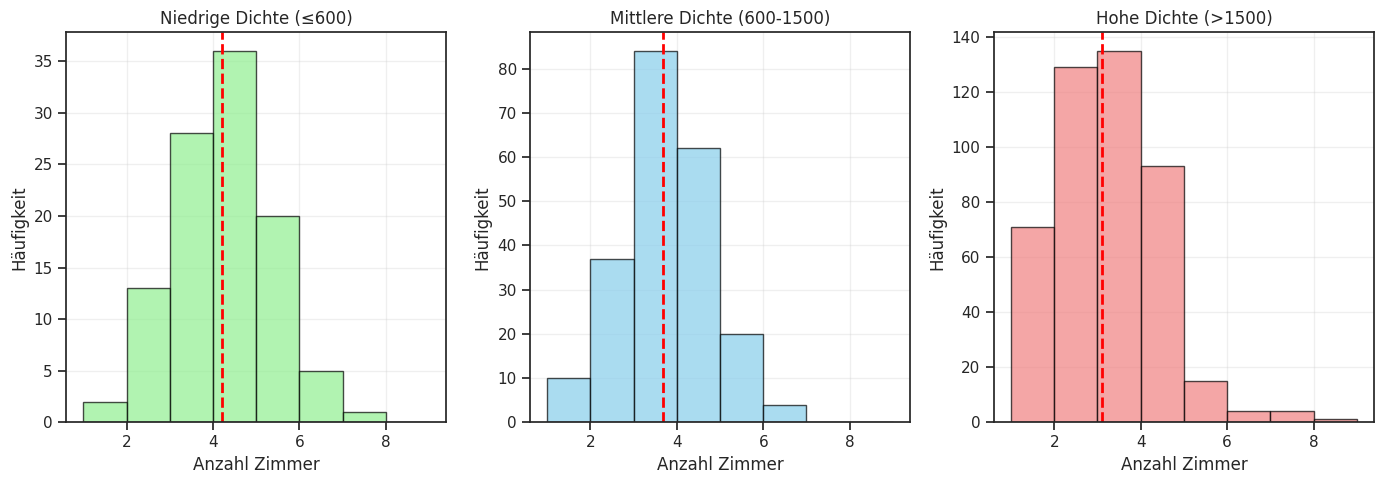

In [42]:
# Visualisierung der Zimmerverteilungen
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(df_low_dens['rooms'], bins=range(1, 10), color='lightgreen', alpha=0.7, edgecolor='black')
plt.axvline(df_low_dens['rooms'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Niedrige Dichte (≤600)')
plt.xlabel('Anzahl Zimmer')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(df_moderate_dens['rooms'], bins=range(1, 10), color='skyblue', alpha=0.7, edgecolor='black')
plt.axvline(df_moderate_dens['rooms'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Mittlere Dichte (600-1500)')
plt.xlabel('Anzahl Zimmer')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(df_high_dens['rooms'], bins=range(1, 10), color='lightcoral', alpha=0.7, edgecolor='black')
plt.axvline(df_high_dens['rooms'].mean(), color='red', linestyle='--', linewidth=2)
plt.title('Hohe Dichte (>1500)')
plt.xlabel('Anzahl Zimmer')
plt.ylabel('Häufigkeit')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# ANOVA durchführen
f_statistic_rooms, p_value_rooms = stats.f_oneway(
    df_low_dens['rooms'],
    df_moderate_dens['rooms'],
    df_high_dens['rooms']
)

print(f"\nF-Statistik: {f_statistic_rooms:.4f}")
print(f"p-Wert: {p_value_rooms:.6f}")

# Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION - ANZAHL ZIMMER")
print("=" * 80)

if p_value_rooms < 0.05:
    print(f"\n✓ Der p-Wert ({p_value_rooms:.6f}) ist kleiner als α = 0.05.")
    print("→ Wir VERWERFEN die Null-Hypothese.")
    print("\nKONKLUSION:")
    print("Es gibt einen statistisch signifikanten Unterschied bei der Anzahl Zimmer")
    print("zwischen den drei Bevölkerungsdichte-Gruppen.")
    print("\nJe niedriger die Bevölkerungsdichte, desto mehr Zimmer haben die Wohnungen tendenziell.")
else:
    print(f"\n✗ Der p-Wert ({p_value_rooms:.6f}) ist größer als α = 0.05.")
    print("→ Wir können die Null-Hypothese NICHT verwerfen.")
    print("\nKONKLUSION:")
    print("Es gibt KEINEN statistisch signifikanten Unterschied bei der Anzahl Zimmer")
    print("zwischen den drei Bevölkerungsdichte-Gruppen.")

print("=" * 80)


F-Statistik: 41.0434
p-Wert: 0.000000

INTERPRETATION - ANZAHL ZIMMER

✓ Der p-Wert (0.000000) ist kleiner als α = 0.05.
→ Wir VERWERFEN die Null-Hypothese.

KONKLUSION:
Es gibt einen statistisch signifikanten Unterschied bei der Anzahl Zimmer
zwischen den drei Bevölkerungsdichte-Gruppen.

Je niedriger die Bevölkerungsdichte, desto mehr Zimmer haben die Wohnungen tendenziell.


### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [44]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-10-26 19:06:44
Python Version: 3.11.13
-----------------------------------
